In [1]:
cd ~/code/glymphopt

/home/jorgen/programs/Dropbox (Simula)/code/glymphopt


In [12]:
import dolfin as df
import matplotlib.pyplot as plt
import numpy as np
import pantarei as pr
import ufl
import subprocess
from glymphopt.utils import apply_affine, cell_midpoints
from glymphopt.measure import create_index_to_coordinates_affine_map, interpolation_measurement, quadrature_measurement
from glymphopt.visual import plot_step

In [13]:
# Define "true" function
f = df.Expression(
    "(abs(x[0]) <= 1 ? 1 : 0.1) * (exp(-pow((x[0] - 0.7)/a1, 2)) + 0.5*exp(-pow((x[0] + 0.6)/a1, 2)))",
    degree=3, a1=0.4
)

In [14]:
# Define MRI-domain/grid, and perform measurement, i.e. map function to array of values
resolution_grid = 64
grid = df.IntervalMesh(resolution_grid, -2.1, 2.1)
aff = create_index_to_coordinates_affine_map(grid) # Find affine of the domain
D_d = quadrature_measurement(f, grid)  # Interpolate centerpoint of "voxels" from function to vector.
ind = np.arange(resolution_grid)
z = apply_affine(aff, ind.reshape(-1, 1))  # Find spatial coordinates of each voxel.

# ADd noise?
# D_d += 0.1 *  D_d * np.random.randn(*D_d.shape)

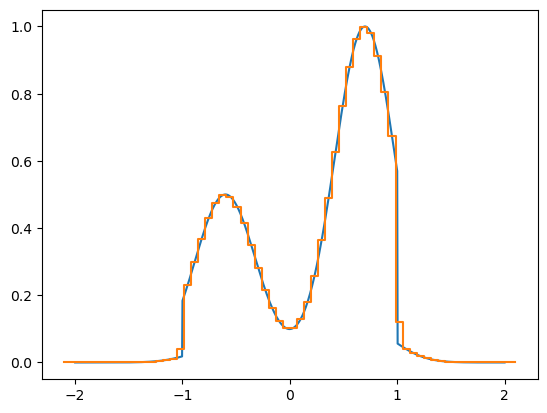

In [15]:
# And plot true function vs. measured values.
domain_fine = df.IntervalMesh(1024, -2, 2)
df.plot(f, mesh=domain_fine)
plot_step(z.flatten(), D_d)
plt.show()

In [16]:
def mri2fem_interpolate(D, lambda_, V, datafilter=None):
    u = df.Function(V)
    z = V.tabulate_dof_coordinates()
    ind = np.rint(apply_affine(np.linalg.inv(lambda_), z)).astype(int)
    n = len(z)
    if datafilter is not None:
        D = datafilter(D)
    u.vector()[:] = D[ind].flatten()
    return u

In [17]:
class InDomain(df.UserExpression):
    """Assign values from a dict to cells labeled by subdomains."""
    def __init__(
        self,
        mesh: df.Mesh,
        **kwargs,
    ):
        super().__init__(kwargs)
        self.mesh = mesh

    def eval_cell(self, value, x, ufc_cell):
        if in_domain(x, self.mesh):
            value[0] = 1.0
        else:
            value[0] = np.nan

    def value_shape(self):
        return ()
    
def simpleplot(u, interval, npoints=401, **kwargs):
    x = np.linspace(*interval, npoints)
    plt.plot(x, [u(xi) for xi in x], **kwargs)

    
def interpolation_measurement(
    f: ufl.Coefficient, measure_domain: df.Mesh
) -> np.ndarray:
    """Interpolate expression/or function onto a DG0-function space"""
    DG0 = df.FunctionSpace(measure_domain, "DG", 0)
    u = df.interpolate(f, DG0)
    return np.array(u.vector())

def in_domain(x, domain):
    first_entity = domain.bounding_box_tree().compute_first_entity_collision(
        df.Point(x)
    )
    return first_entity <= domain.num_entities(domain.geometric_dimension())

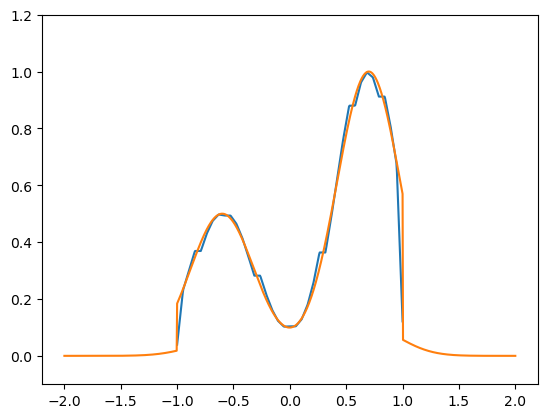

In [19]:
resolution_mesh = int(0.6 * resolution_grid)
domain = df.IntervalMesh(resolution_mesh, -1, 1)
CG1 = df.FunctionSpace(domain, "CG", 1)
ch = mri2fem_interpolate(D_d, aff, CG1)
ch.set_allow_extrapolation(True)

simpleplot(ch, (-1, 1))
df.plot(f, mesh=domain_fine)
# plot_step(z.flatten(), D_d, lw=1)
plt.ylim(-0.1, 1.2)
plt.show()

In [9]:
def rel_voxelwise_err(D_p, D_d, f = None):
    if f is None:
        return (D_p - D_d) / D_d
    return f(D_p) - f(D_d) / f(D_d)
    
    
def mean_relative_voxelwise_err(D_p, D_d):
    return (D_p - D_d) / np.nanmean(D_d)


def median_relative_voxelwise_err(D_p, D_d):
    return (D_p - D_d) / np.nanmedian(D_d)


from scipy.spatial import distance

def global_p_norm_error(D_p, D_d, p):
    mask = ~np.isnan(D_p)
    vec_p, vec_d = D_p[mask], D_d[mask]
    return np.linalg.norm(vec_p - vec_d, ord=p) /  (np.linalg.norm(vec_p, ord=p) * np.linalg.norm(vec_d, ord=p))

def global_cosine_error(D_p, D_d):
    mask = ~np.isnan(D_p)
    vec_p, vec_d = D_p[mask], D_d[mask]
    return distance.cosine(vec_p, vec_d)


def global_score_error(D_p, D_d, f):
    mask = ~np.isnan(D_p)
    vec_p, vec_d = D_p[mask], D_d[mask]
    return (f(vec_p) - f(vec_d)) / f(vec_d)

In [10]:
maskfunc = InDomain(domain)
mask = interpolation_measurement(maskfunc, grid)
D_p = mask * interpolation_measurement(ch, grid)

Building point search tree to accelerate distance queries.
Computed bounding box tree with 75 nodes for 38 points.


In [11]:
print("Global 1-norm error:", global_p_norm_error(D_p, D_d, 1))
print("Global 2-norm error:", global_p_norm_error(D_p, D_d, 2))
print("Global cosine-error:", global_cosine_error(D_p, D_d))
print("Global mean   error:", global_score_error(D_p, D_d, np.mean))
print("Global median error:", global_score_error(D_p, D_d, np.median))

Global 1-norm error: 0.001690666172691628
Global 2-norm error: 0.01024398745962145
Global cosine-error: 0.0004678711731543883
Global mean   error: 0.0016104963762618694
Global median error: -0.018302235166287407


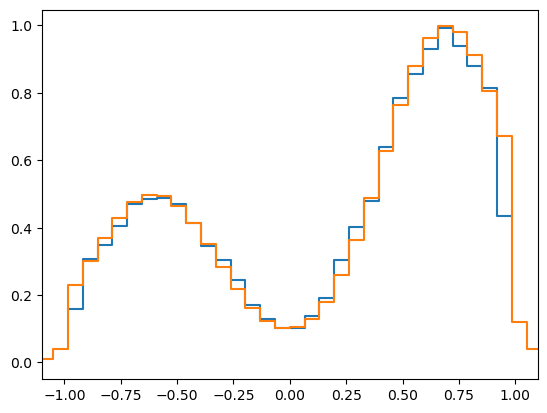

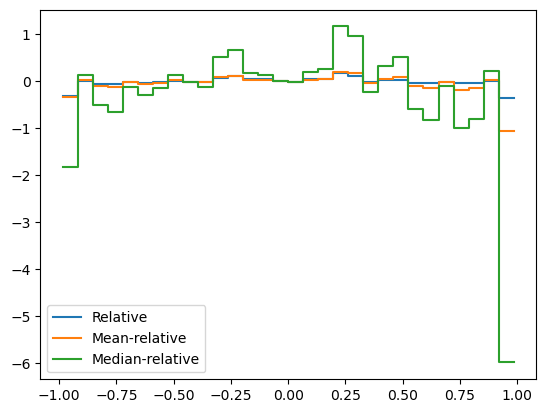

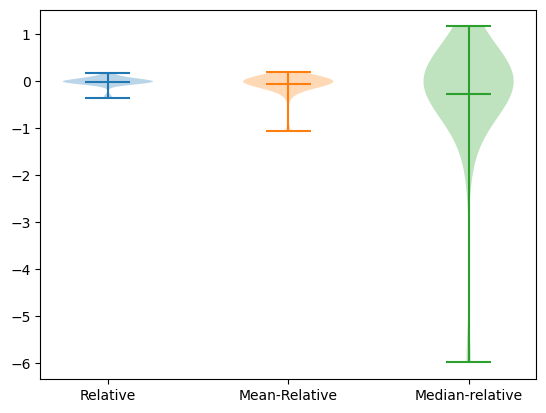

In [415]:
plot_step(z.flatten(), D_p, label="Processed")
plot_step(z.flatten(), D_d, label="Target")
plt.xlim(-1.1, 1.1)
plt.show()

e = rel_voxelwise_err(D_p, D_d)
e_mean = mean_relative_voxelwise_err(D_p, D_d)
e_median = median_relative_voxelwise_err(D_p, D_d)
plot_step(z.flatten(), e, label="Relative")
plot_step(z.flatten(), e_mean, label="Mean-relative")
plot_step(z.flatten(), e_median, label="Median-relative")
plt.legend()
plt.show()

plt.figure()
plt.violinplot(e[~np.isnan(e)], [0], showmeans=True)
plt.violinplot(e_mean[~np.isnan(e_mean)], [1], showmeans=True)
plt.violinplot(e_median[~np.isnan(e_median)], [2], showmeans=True)
plt.xticks([0, 1, 2], ["Relative", "Mean-Relative", "Median-relative"])
plt.show()

In [416]:
def mridata2function(D: np.ndarray, affine: np.ndarray, domain: df.Mesh) -> df.Function:
    affine_inv = np.linalg.inv(affine)

    # Map from array-data to DG0-function space on regular grid.
    N = len(D)
    grid = pr.MMSInterval(N)
    DG0 = df.FunctionSpace(grid, "DG", 0)
    c_dg0 = df.Function(DG0)
    dofs_coordinates = DG0.tabulate_dof_coordinates()
    ind = np.rint(apply_affine(affine_inv, dofs_coordinates)).astype(int)
    c_dg0.vector()[:] = D[ind].flatten()

    # Project DG0-function onto CG1-function with same grid values.
    CG1 = df.FunctionSpace(grid, "CG", 1)
    c_cg1 = df.Function(CG1)
    c_cg1 = df.project(c_dg0, CG1)

    # Interpolate CG1-function from regular grid, to CG1 on mesh.
    CG1 = df.FunctionSpace(domain, "CG", 1)
    c = df.Function(CG1, name="concentration")
    c.assign(df.interpolate(c_cg1, CG1))
    return c

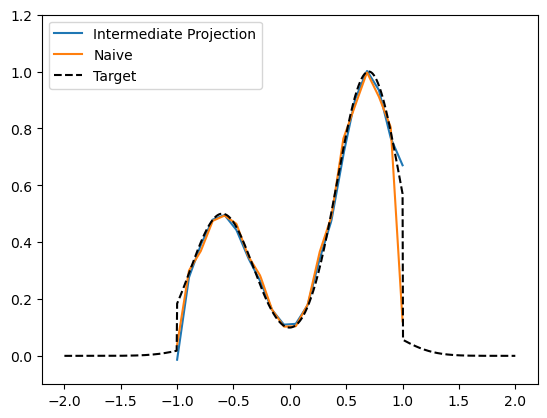

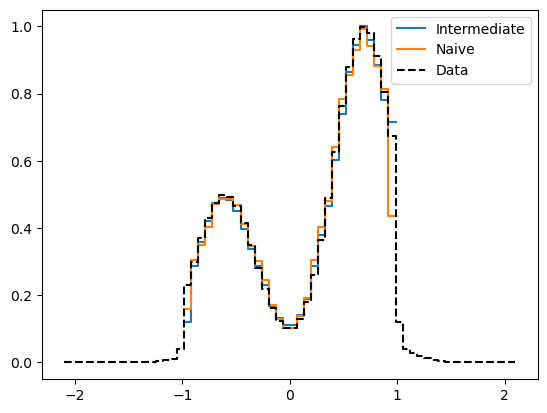

In [417]:
c = mridata2function(D_d, aff, domain)
c.set_allow_extrapolation(True)

simpleplot(c, (-1, 1), label="Intermediate Projection")
simpleplot(ch, (-1, 1), label="Naive")
df.plot(f, mesh=domain_fine, label="Target", c="k", ls="--")
plt.ylim(-0.1, 1.2)
plt.legend()
plt.show()

mask = interpolation_measurement(maskfunc, grid)
D_p = mask * interpolation_measurement(c, grid)
D_pold = mask * interpolation_measurement(ch, grid)


plot_step(z.flatten(), D_p, label="Intermediate")
plot_step(z.flatten(), D_pold, label="Naive")
plot_step(z.flatten(), D_d, label="Data", c="k", ls="--")
plt.legend()
plt.show()

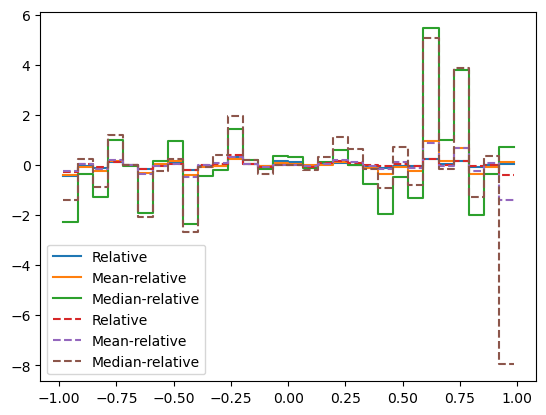

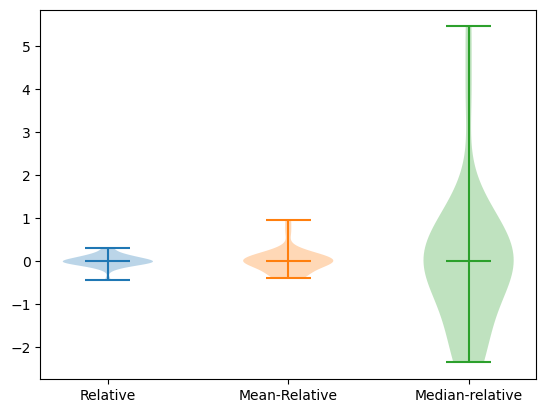

In [404]:
e_old = rel_voxelwise_err(D_pold, D_d)
e_mean_old = mean_relative_voxelwise_err(D_pold, D_d)
e_median_old = median_relative_voxelwise_err(D_pold, D_d)

e = rel_voxelwise_err(D_p, D_d)
e_mean = mean_relative_voxelwise_err(D_p, D_d)
e_median = median_relative_voxelwise_err(D_p, D_d)
plot_step(z.flatten(), e, label="Relative")
plot_step(z.flatten(), e_mean, label="Mean-relative")
plot_step(z.flatten(), e_median, label="Median-relative")
plot_step(z.flatten(), e_old, label="Relative", ls="--")
plot_step(z.flatten(), e_mean_old, label="Mean-relative", ls="--")
plot_step(z.flatten(), e_median_old, label="Median-relative", ls="--")
plt.legend()
plt.show()

plt.figure()
plt.violinplot(e[~np.isnan(e)], [0], showmeans=True)
plt.violinplot(e_mean[~np.isnan(e_mean)], [1], showmeans=True)
plt.violinplot(e_median[~np.isnan(e_median)], [2], showmeans=True)
plt.xticks([0, 1, 2], ["Relative", "Mean-Relative", "Median-relative"])
plt.show()

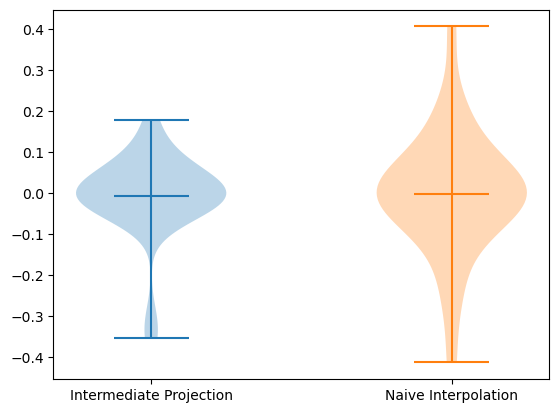

In [420]:
plt.figure()
plt.violinplot(e[~np.isnan(e)], [0], showmeans=True)
plt.violinplot(e_old[~np.isnan(e)], [1], showmeans=True)
plt.xticks([0, 1], ["Intermediate Projection", "Naive Interpolation"])
plt.show()

In [405]:
print("Global 1-norm error:", global_p_norm_error(D_p, D_d, 1))
print("Global 2-norm error:", global_p_norm_error(D_p, D_d, 2))
print("Global cosine-error:", global_cosine_error(D_p, D_d))
print("Global mean   error:", global_score_error(D_p, D_d, np.mean))
print("Global median error:", global_score_error(D_p, D_d, np.median))

Global 1-norm error: 0.006261067146388797
Global 2-norm error: 0.03598169891324702
Global cosine-error: 0.006075002590085754
Global mean   error: 0.000119894507212969
Global median error: -0.011526177324510176


In [406]:
print("Global 1-norm error:", global_p_norm_error(D_pold, D_d, 1))
print("Global 2-norm error:", global_p_norm_error(D_pold, D_d, 2))
print("Global cosine-error:", global_cosine_error(D_pold, D_d))
print("Global mean   error:", global_score_error(D_pold, D_d, np.mean))
print("Global median error:", global_score_error(D_pold, D_d, np.median))

Global 1-norm error: 0.007003225315541416
Global 2-norm error: 0.04719190988512866
Global cosine-error: 0.010504809845686913
Global mean   error: -0.008174312683554114
Global median error: 0.0023943345029454484


In [15]:
def simpleplot(u, interval, npoints=401, **kwargs):
    x = np.linspace(*interval, npoints)
    plt.plot(x, [u(xi) for xi in x], **kwargs)

Building point search tree to accelerate distance queries.


(-0.1, 0.5)

Computed bounding box tree with 4095 nodes for 2048 points.


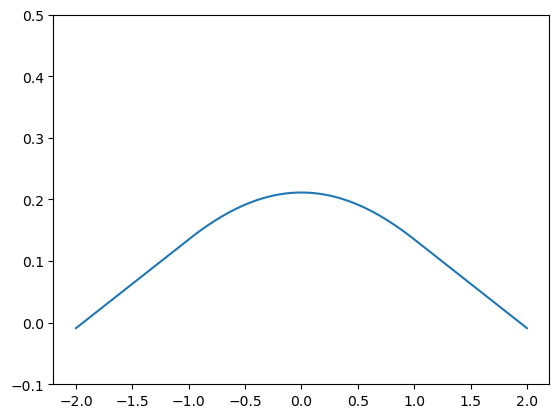

In [19]:
c_sample = pr.interpolate_from_file(sim_path, "concentration", measure_time)
c_sample.set_allow_extrapolation(True)
simpleplot(c_sample, (-2, 2))
plt.ylim(-0.1, 0.5)

In [ ]:
plt.show()